# Power Law Analysis of Public Employees Salaries From Brazil/SP 2012-2023

## Objective
This notebook analyzes the distribution of Public Employees Salaries From Brazil/SP 2012-2023. We will use the `powerlaw` package to fit the distribution and investigate if it follows a power law.

## Requirements
```bash
pip install powerlaw pandas matplotlib numpy
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import powerlaw

# Configure matplotlib style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading
Loading the `2022_merged.csv` file and extracting the `net salaries` column.

In [34]:
file_path = r'd:/financedtata/2022_merged.csv'
print(f"Reading data from {file_path}...")

# Read only the salary column to save memory if dataset is huge
df = pd.read_csv(file_path, usecols=[6], dtype=str).values
salary_data = np.zeros(len(df))
for i in range(len(df)):
    a = df[i].item()
    salary_data[i] = float(a.split(";")[1])
print(f"Loaded {len(salary_data)} records.")
print(f"Max salary: {np.max(salary_data)}")
print(f"Min salary: {np.min(salary_data)}")

Reading data from d:/financedtata/2022_merged.csv...


Loaded 11802493 records.
Max salary: 798723.0
Min salary: -89224.0


## 2. Preprocessing
Power law fitting requires positive values ($x > 0$). We will filter out zero or negative trip distances.

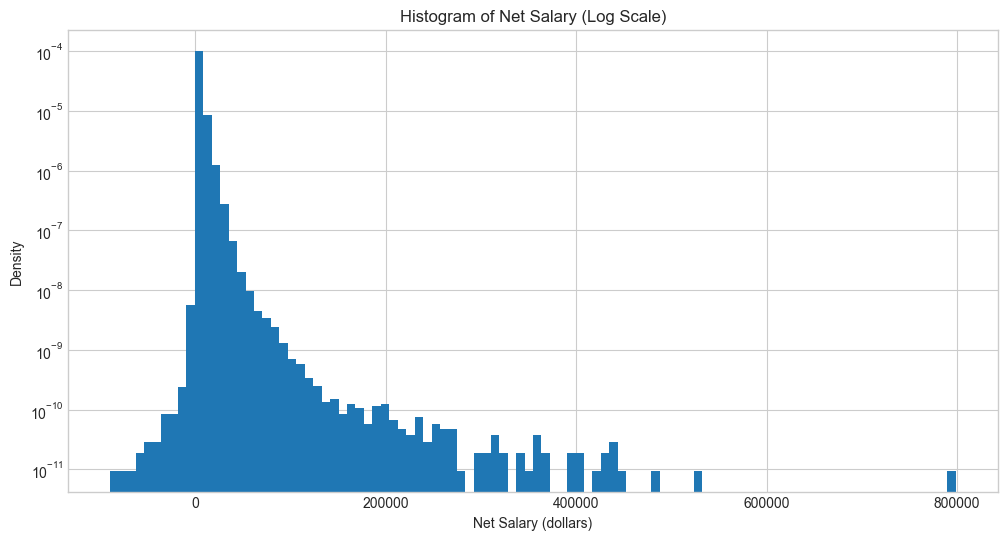

In [ ]:
original_count = len(salary_data)

# At first, we can take a look at the data distribution
plt.figure(figsize=(12, 6))
plt.hist(salary_data, bins=100, log=True, density=True)
plt.title('Histogram of Net Salary (Log Scale)')
plt.xlabel('Net Salary (dollars)')
plt.ylabel('Density')
plt.show()

In [41]:
# Filter strictly positive values
original_count = len(salary_data)

# Get the values between 0 and 600000 dollars
salary_data = salary_data[(salary_data > 0) & (salary_data<=600000)]
filtered_count = len(salary_data)

print(f"Removed records with <= 0 dollars and above 600000 dollars: {original_count - filtered_count} and NA.")
print(f"Remaining records: {len(salary_data)}")

Removed records with <= 0 dollars and above 600000 dollars: 0 and NA.
Remaining records: 11748715


## 3. Exploratory Data Analysis
Visualizing the distribution of trip distances.

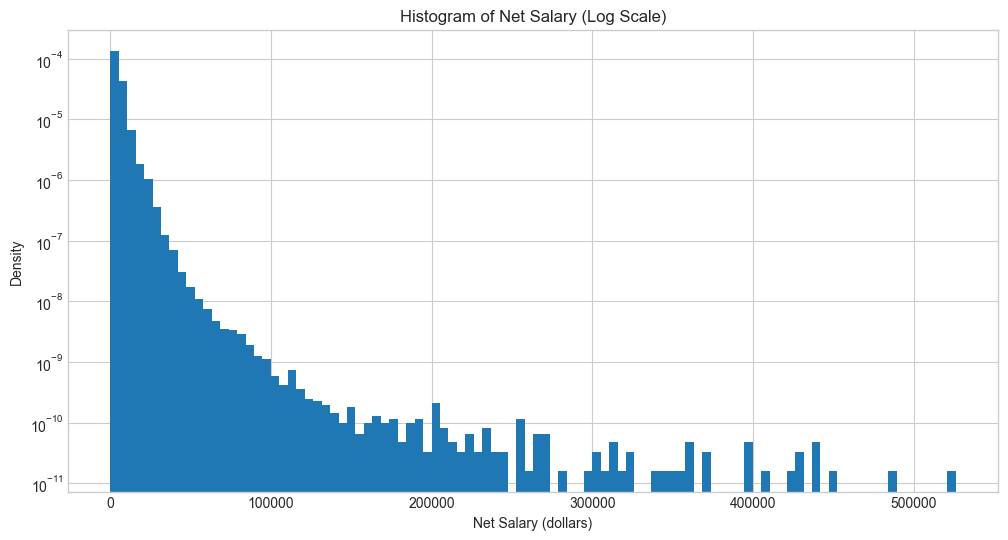

In [43]:
plt.figure(figsize=(12, 6))
plt.hist(salary_data, bins=100, log=True, density=True)
plt.title('Histogram of Net Salary (Log Scale)')
plt.xlabel('Net Salary (dollars)')
plt.ylabel('Density')
plt.show()

## 3.1 Normal Distribution Comparison
Comparing the empirical distribution with a Normal distribution (same mean and variance) on a log-log scale.
If the data contains both positive and negative values, we plot the distributions of the absolute values.

Empirical Mean: 4578.1317
Empirical Std Dev: 3888.1140


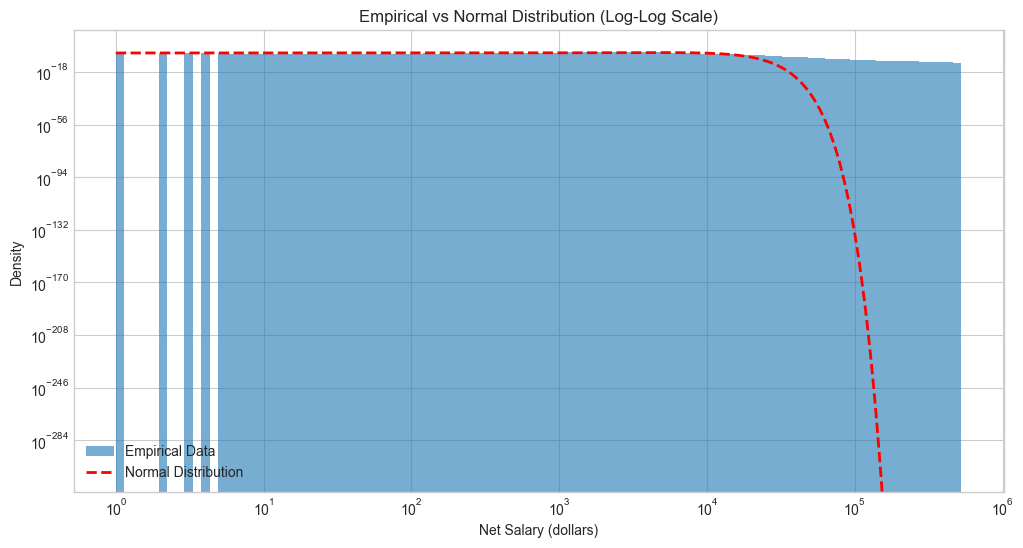

In [45]:
import scipy.stats as stats

# Use absolute values (though data is already filtered positive)
abs_data = np.abs(salary_data)

# Calculate empirical mean and variance
mu = np.mean(abs_data)
sigma = np.std(abs_data)
print(f"Empirical Mean: {mu:.4f}")
print(f"Empirical Std Dev: {sigma:.4f}")

# Generate Normal distribution
x = np.linspace(min(abs_data), max(abs_data), 1000)
pdf_normal = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(12, 6))

# Plot Empirical Distribution
# Using log-spaced bins for better visibility on log-log scale
bins = np.logspace(np.log10(min(abs_data)), np.log10(max(abs_data)), 100)
plt.hist(abs_data, bins=bins, density=True, alpha=0.6, label='Empirical Data')

# Plot Normal Distribution
plt.plot(x, pdf_normal, 'r--', linewidth=2, label='Normal Distribution')

plt.xscale('log')
plt.yscale('log')
plt.title('Empirical vs Normal Distribution (Log-Log Scale)')
plt.xlabel('Net Salary (dollars)')
plt.ylabel('Density')
plt.legend()
plt.show()

## 3.2 Percentile Comparison
Calculating the 99.99th percentile for both the empirical and Normal distributions to compare their tails.

In [46]:
# 99.99th percentile of Empirical Data
p9999_empirical = np.percentile(abs_data, 99.99)

# 99.99th percentile of Normal Distribution
# using mu and sigma from the previous cell
p9999_normal = stats.norm.ppf(0.9999, loc=mu, scale=sigma)

print(f"99.99th Percentile (Empirical): {p9999_empirical:.4f}")
print(f"99.99th Percentile (Normal): {p9999_normal:.4f}")
print(f"Difference (Empirical - Normal): {p9999_empirical - p9999_normal:.4f}")

print("\nComment on the difference:")
if p9999_empirical > p9999_normal:
    print("The empirical 99.99th percentile is significantly larger than the Normal distribution's.")
    print("This indicates that the empirical distribution has much heavier tails (more extreme values) than a Normal distribution.")
else:
    print("The empirical 99.99th percentile is similar to or smaller than the Normal distribution's.")

99.99th Percentile (Empirical): 68966.4434
99.99th Percentile (Normal): 19038.0918
Difference (Empirical - Normal): 49928.3516

Comment on the difference:
The empirical 99.99th percentile is significantly larger than the Normal distribution's.
This indicates that the empirical distribution has much heavier tails (more extreme values) than a Normal distribution.


## 4. Fitting a Power Law Distribution
Using `powerlaw.Fit` to estimate the parameters $\alpha$ and $x_{min}$.

In [54]:
print("Fitting power law distribution (this might take a moment)...")
fit = powerlaw.Fit(salary_data)

print(f"Optimal x_min: {fit.xmin:.4f}")
print(f"Alpha: {fit.alpha:.4f}")
print(f"Sigma: {fit.sigma:.4f}")
print(f"D (Kolmogorov-Smirnov distance): {fit.D:.4f}")

Fitting power law distribution (this might take a moment)...
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 14085/14085 [03:38<00:00, 64.54it/s] 


Optimal x_min: 3633.0000
Alpha: 2.9994
Sigma: 0.0079
D (Kolmogorov-Smirnov distance): 0.1289


## 5. Visualizing the Fit
Plotting the PDF and CCDF to visually inspect the quality of the fit.

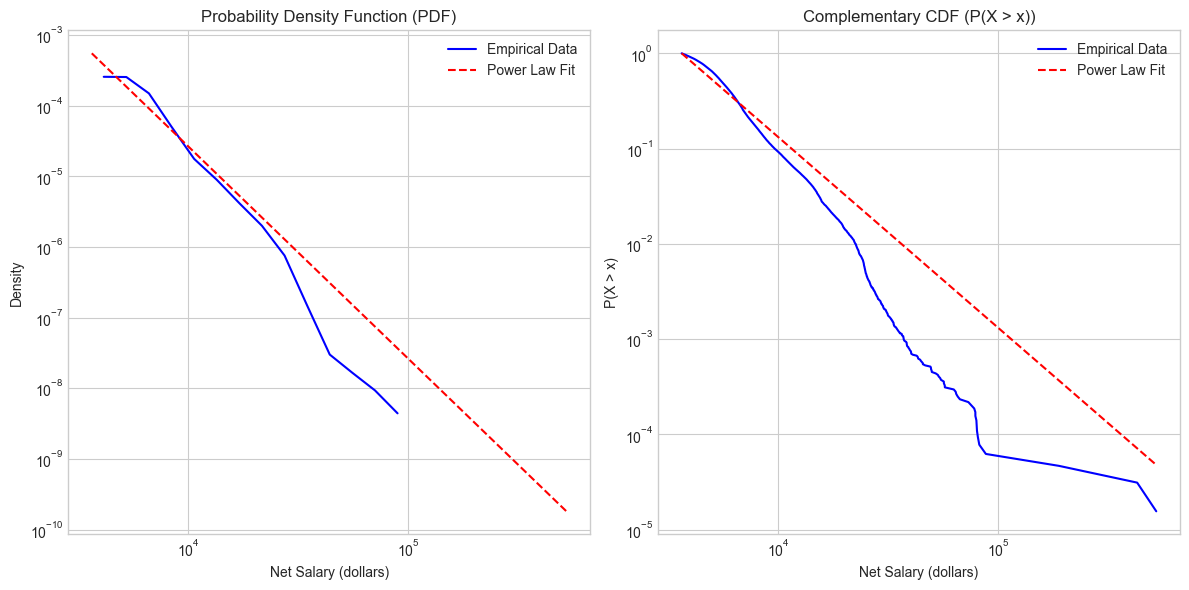

In [59]:
fig = plt.figure(figsize=(12, 6))

# PDF
ax1 = fig.add_subplot(121)
fit.plot_pdf(color='b', linear_bins=False, ax=ax1, label='Empirical Data')
fit.power_law.plot_pdf(color='r', linestyle='--', ax=ax1, label='Power Law Fit')
ax1.set_title('Probability Density Function (PDF)')
ax1.set_xlabel('Net Salary (dollars)')
ax1.set_ylabel('Density')
ax1.legend()

# CCDF
ax2 = fig.add_subplot(122)
fit.plot_ccdf(color='b', ax=ax2, label='Empirical Data')
fit.power_law.plot_ccdf(color='r', linestyle='--', ax=ax2, label='Power Law Fit')
ax2.set_title('Complementary CDF (P(X > x))')
ax2.set_xlabel('Net Salary (dollars)')
ax2.set_ylabel('P(X > x)')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Distribution Comparison
Comparing Power Law vs. Lognormal and Exponential distributions.

In [ ]:
R, p = fit.distribution_compare('power_law', 'lognormal')
print(f"Power Law vs. Lognormal: R = {R:.4f}, p = {p:.4f}")
if R > 0:
    print("Power Law is a better fit.")
else:
    print("Lognormal is a better fit.")

print("-" * 20)

R, p = fit.distribution_compare('power_law', 'exponential')
print(f"Power Law vs. Exponential: R = {R:.4f}, p = {p:.4f}")
if R > 0:
    print("Power Law is a better fit.")
else:
    print("Exponential is a better fit.")